In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [2]:

import requests

# URL for the raw titanic train.csv from a common GitHub repository
titanic_url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

# Download the file
response = requests.get(titanic_url)
with open('titanic.csv', 'wb') as f:
    f.write(response.content)


In [3]:
titanic= pd.read_csv('titanic.csv', on_bad_lines="skip")
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic['Age'].fillna(titanic['Age'].median(), inplace=True)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/tmp/ipython-input-3766794809.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['Age'].fillna(titanic['Age'].median(), inplace=True)


In [ ]:
import numpy as np
titanic.select_dtypes(include=np.number).cov()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


In [ ]:
import numpy as np
titanic.select_dtypes(include=np.number).corr()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


In [ ]:
#titanic.shape        (891, 12)
#titanic.isnull().sum()               to many null in cabin

#titanic.duplicated().sum()            np.int64(0) ------>   no duplicates

np.int64(0)

# 1. Univariate EDA

<Axes: xlabel='count', ylabel='Survived'>

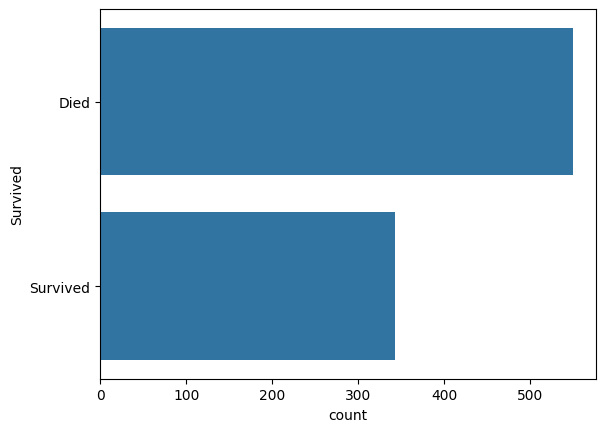

In [ ]:
sns.countplot(titanic['Survived'].map({0:'Died', 1:'Survived'}))

<Axes: xlabel='Age', ylabel='Count'>

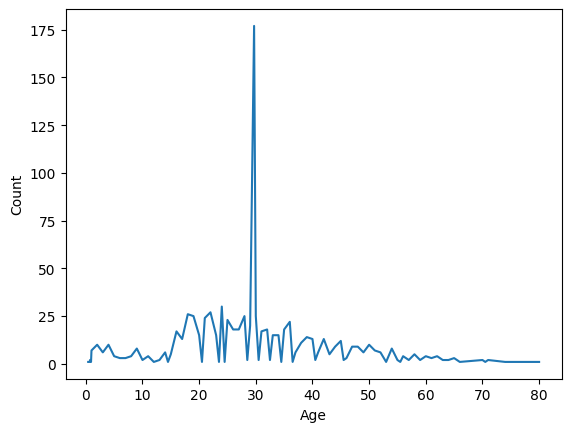

In [ ]:
age_counts = titanic['Age'].value_counts().sort_index().reset_index()
age_counts.columns = ['Age', 'Count']
sns.lineplot(x='Age', y='Count', data=age_counts)

/tmp/ipython-input-3001370571.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic['Fare'])


<Axes: xlabel='Fare', ylabel='Density'>

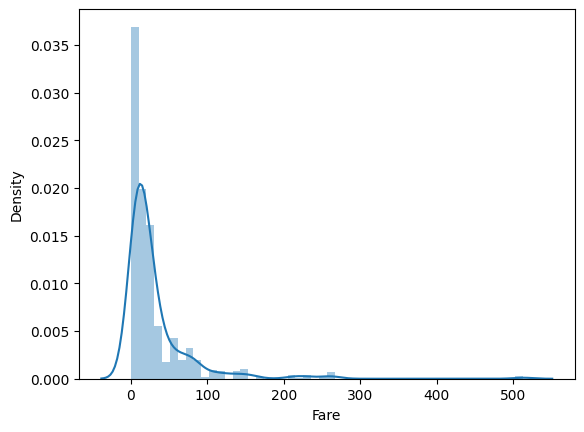

In [ ]:
sns.distplot(titanic['Fare'])              # the fare price was mostly cheap but few outliers

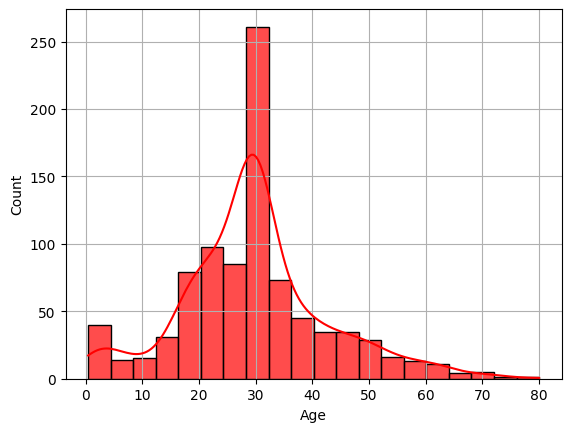

In [ ]:
sns.histplot(titanic['Age'], bins=20, kde=True, color='red', edgecolor='black',
             linewidth=1, alpha=0.7, stat='count')
plt.grid(True)

In [ ]:
titanic['Age'].skew()

np.float64(0.4344880940129925)

<Axes: xlabel='Sex', ylabel='Count'>

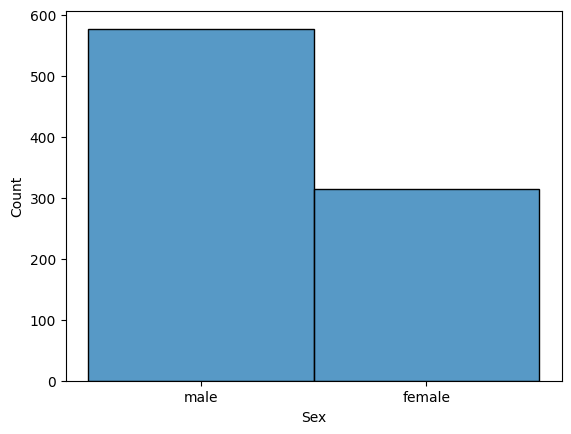

In [ ]:
sns.histplot(titanic['Sex'])

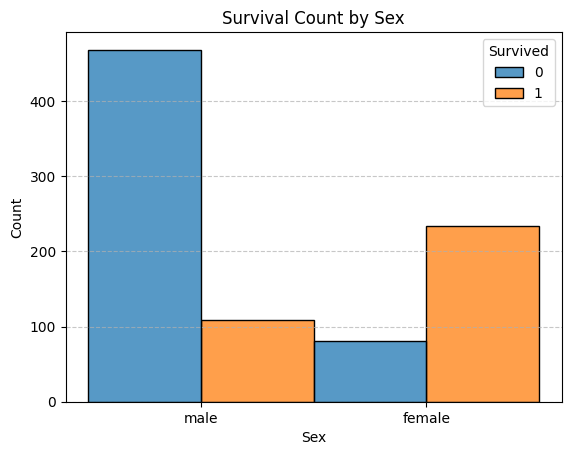

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.histplot(data=titanic, x='Sex', hue='Survived', multiple='dodge')

# Calculate total counts for each sex
sex_counts = titanic['Sex'].value_counts()

# Get x-tick positions and labels for annotation placement
x_ticks = ax.get_xticks()
x_labels = [label.get_text() for label in ax.get_xticklabels()]

# Iterate through the x-labels to place annotations correctly
for i, label in enumerate(x_labels):
    total = sex_counts.get(label, 0)
    # Place text slightly above the highest point for that sex group
    # The total height for a sex group is the sum of its 'Survived' and 'Died' counts.
    ax.text(x_ticks[i], total + (ax.get_ylim()[1] * 0.03), # Add 3% of y-axis range as buffer
            f'Total: {total}',
            ha='center', va='bottom', fontsize=9, color='black', weight='bold')

plt.title('Survival Count by Sex with Total Counts') # Update title for clarity
plt.xlabel('Sex')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Bivariate EDA

<Axes: xlabel='Pclass', ylabel='Age'>

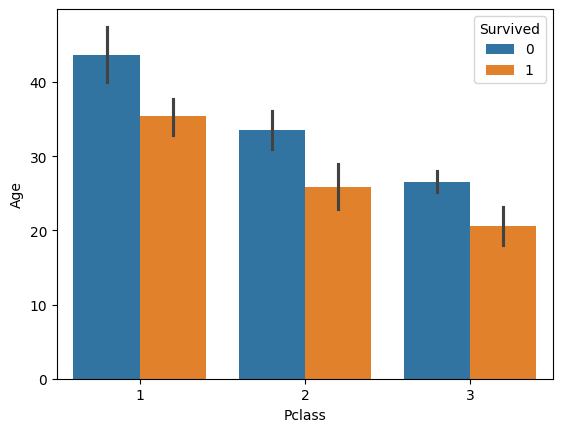

In [12]:
#sns.barplot(x=titanic['Pclass'], y=titanic['Age'], hue=titanic['Survived'] )
sns.barplot(x='Pclass', y='Age', hue='Survived', data= titanic )

<Axes: xlabel='Age', ylabel='Fare'>

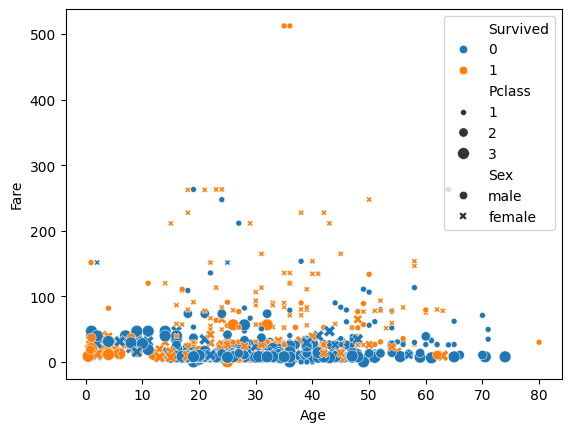

In [33]:
sns.scatterplot(x='Age', y='Fare', hue='Survived',style='Sex',size='Pclass', data=titanic)        #Elder paid the minimum fare, and no survival after age> ~64
                                                                                    #younger child were saved, but too young were death
                                                                                    # People who paid more have higher chances for survival, mostly women paid more

In [61]:
survival_counts = df.unstack(level='Survived')
survival_counts['total passengers']= survival_counts[0]+survival_counts[1]
survival_counts['Survival_Ratio'] = (survival_counts[1]/ survival_counts['total passengers'])*100
print(survival_counts)

# 2/3==62% three people in pclass 1(highest paid), was survived, ( women paid the most)
# 1/4==24%  were survived from the pclass3

#pd.crosstab(titanic['Pclass'], titanic['Survived'])


Survived    0    1  total passengers  Survival_Ratio
Pclass                                              
1          80  136               216       62.962963
2          97   87               184       47.282609
3         372  119               491       24.236253


<Axes: xlabel='Pclass', ylabel='Fare'>

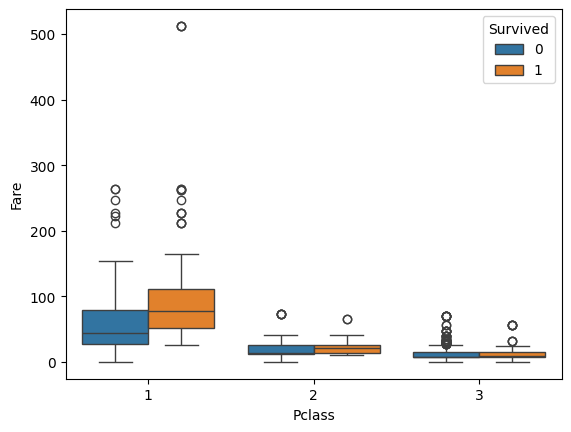

In [43]:
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=titanic)

# people who paid moore like outlier, are from the pclass1
# not many outliers from pclass2, that means people deciding pclass1, or pclaas3 instead
# fare for pclass 1 is more varying and broden than other two classes

# it can be observed , the difference between dead and survival , was bigger in pclass1

# the fare prize ends for one class is the starting point for other, which is basic

/tmp/ipython-input-1396325505.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']== 0]['Age'],hist=False, label='Died')
/tmp/ipython-input-1396325505.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic[titanic['Survived']== 1]['Age'],hist=Fal

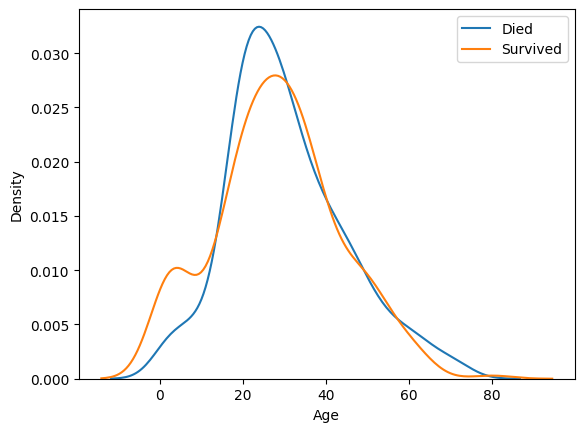

In [46]:
sns.distplot(titanic[titanic['Survived']== 0]['Age'],hist=False, label='Died')
sns.distplot(titanic[titanic['Survived']== 1]['Age'],hist=False, label='Survived')
plt.legend()

# there number are just approximates
# When age<18,  chances of survival is higher
# When 19<age<35  chances of dying is higher
# when 35<age<55   chances are almost equal
# when age is >57  chances of deatch is higher


In [49]:
import plotly.express as px

# Create an interactive histogram of 'Age'
fig = px.histogram(titanic, x='Age', nbins=20, title='Interactive Age Distribution (Histogram)',
                   labels={'Age': 'Age of Passengers', 'count': 'Number of Passengers'})
fig.show()

You can also create an interactive kernel density estimate plot (similar to the density part of `distplot`) using `plotly.express.density_contour`:


In [52]:
fig = px.density_contour(titanic, x='Age',y='Fare', title='Interactive Age Distribution (Density Contour)',
                         labels={'Age': 'Age of Passengers'})
fig.show()

Use istplot for understanding , not numbers


<Axes: >

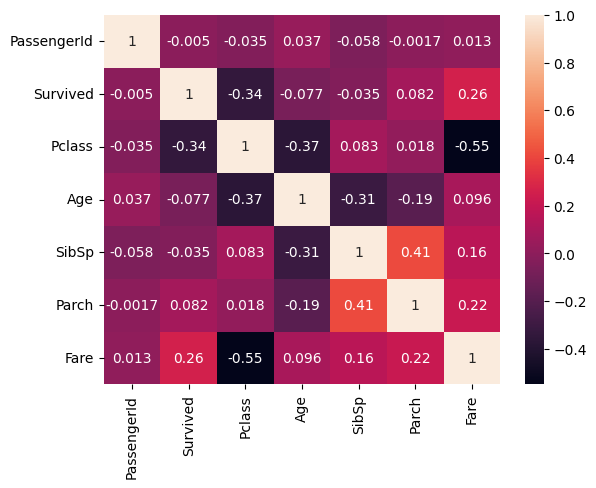

In [58]:
sns.heatmap(titanic.select_dtypes(include=np.number).corr(), annot=True)

need to work on sibsp, parch and pclass


<Axes: xlabel='Survived', ylabel='Pclass'>

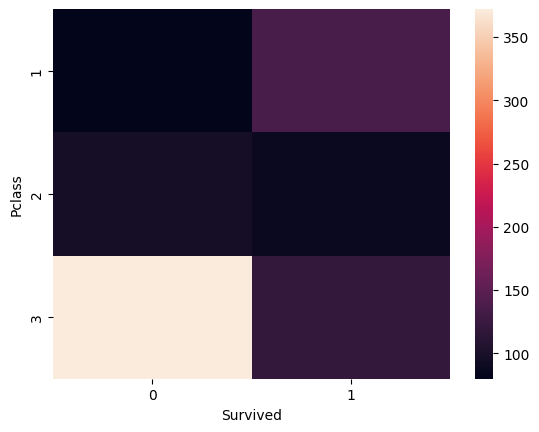

In [62]:
pd.crosstab(titanic['Pclass'], titanic['Survived'])
sns.heatmap(pd.crosstab(titanic['Pclass'], titanic['Survived']))

In [65]:
titanic.groupby(['Pclass'])['Age'].mean()              # Pclass follows age higher to lower

,Age
Pclass,
1,38.233441
2,29.877630
3,25.140620


In [77]:
df2 = titanic.groupby(['Pclass','Survived']).agg(
    MeanFare=('Fare', 'mean'),
    MeanAge=('Age', 'mean')
)
print(df2)
# Even in each class, people who paid more survived more
# and if 'Age' is considered, people who are younger in each class survived more

                  MeanFare    MeanAge
Pclass Survived                      
1      0         64.684007  43.695312
       1         95.608029  35.368197
2      0         19.412328  33.544444
       1         22.055700  25.901566
3      0         13.669364  26.555556
       1         13.694887  20.646118


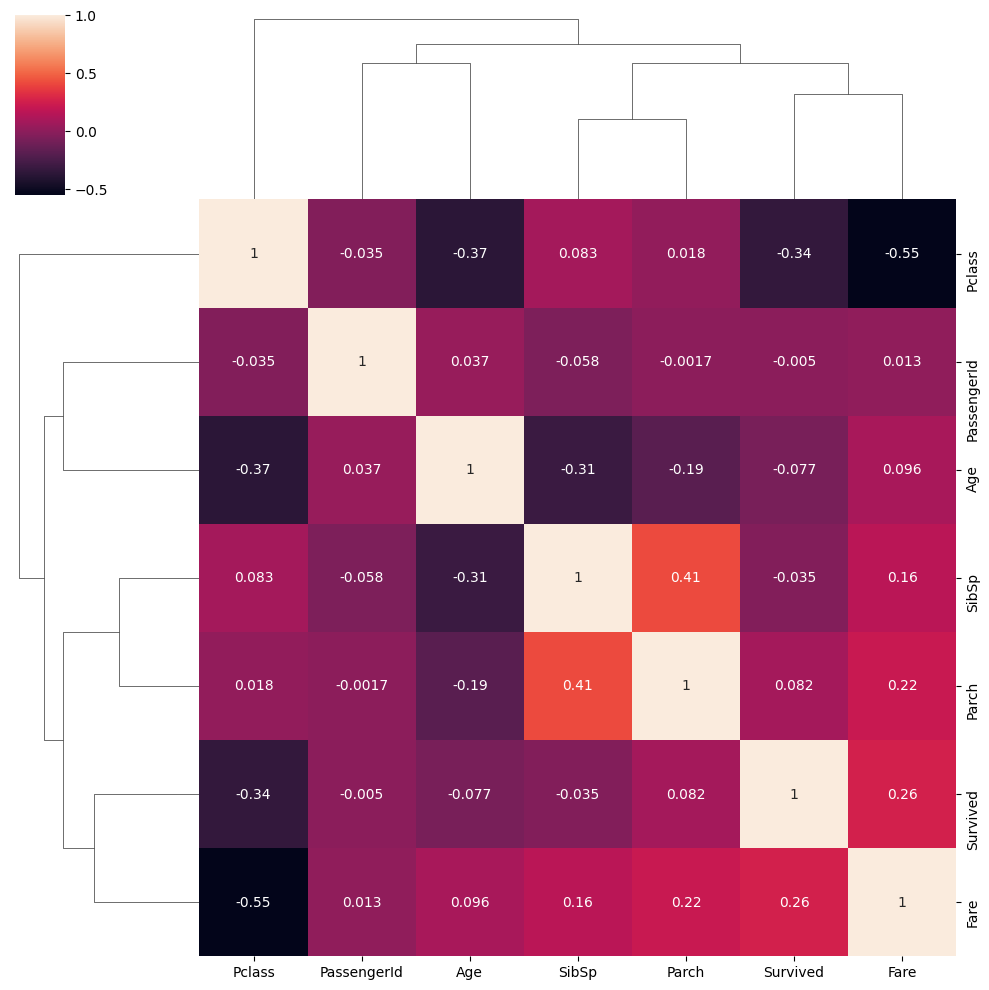

In [78]:
sns.clustermap(titanic.select_dtypes(include=np.number).corr(), annot=True)

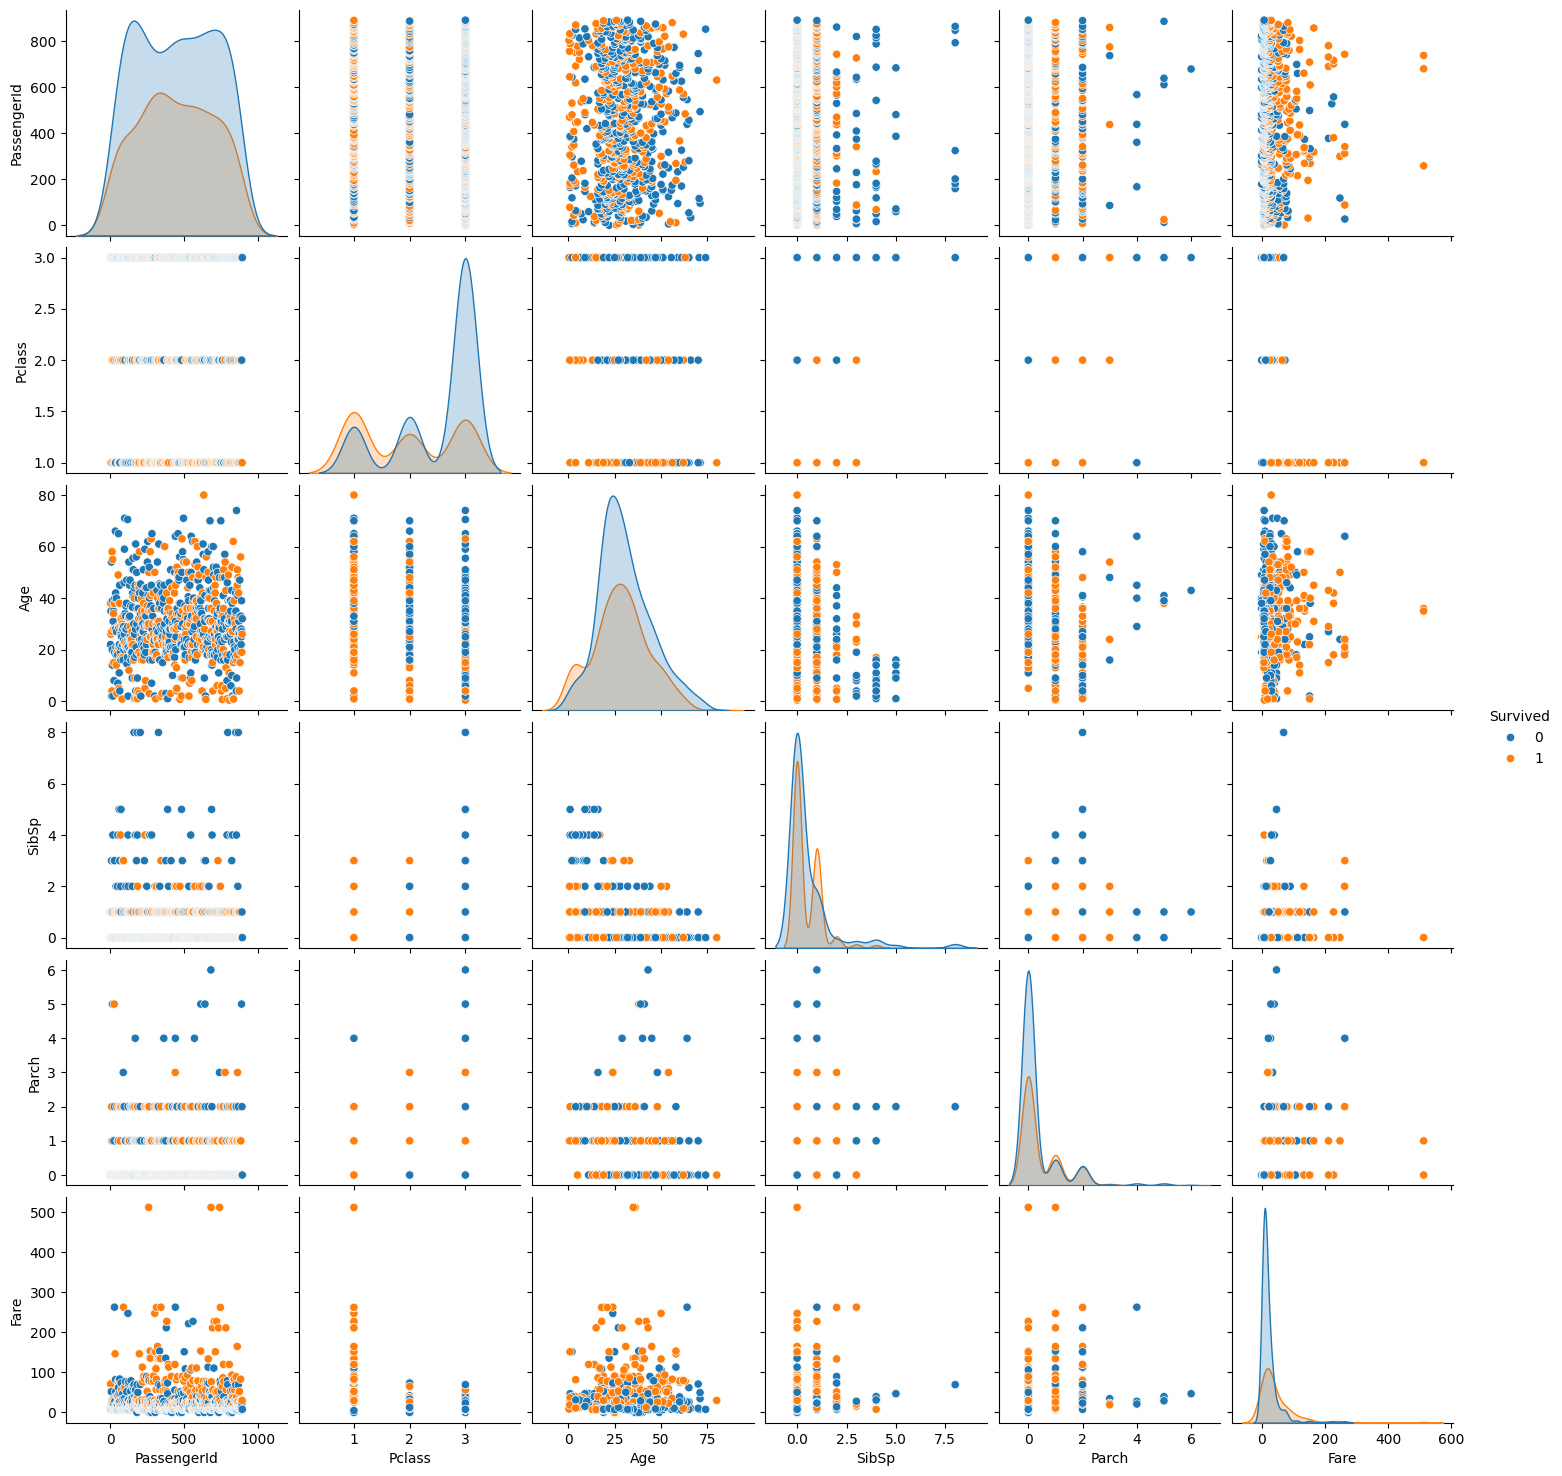

In [81]:
sns.pairplot(titanic, hue='Survived', diag_kind='kde')

<Axes: xlabel='Age', ylabel='Fare'>

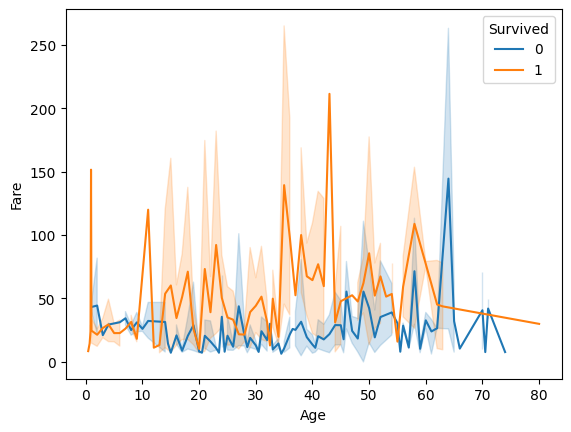

In [83]:
sns.lineplot(x='Age', y='Fare', hue='Survived', data=titanic)
# this tells many things

In [84]:
pivot_table = titanic.pivot_table(index='Pclass', columns='Survived', values='Age', aggfunc='mean')
print(pivot_table)

Survived          0          1
Pclass                        
1         43.695312  35.368197
2         33.544444  25.901566
3         26.555556  20.646118


In [1]:
!pip install ydata-profiling

In [5]:
from ydata_profiling import ProfileReport
profile = ProfileReport(titanic, title="Titanic Report")
profile.to_file("titanic_report.html")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 50.37it/s]


### EDA is about understanding, not modeling
- Shape, patterns, problems, surprises.

### Always start with basics

- shape, info(), describe()

### Data types matter more than you think.

### -Missing values ≠ random

- Ask why they are missing before filling or dropping.

- Outliers tell stories

- They can be errors or important signals. Don’t delete blindly.

### Target variable first

- Distribution, imbalance, skewness → affects model choice.

### Correlation ≠ causation

High correlation is a hint, not proof.

### Visuals > tables

- Histograms, boxplots, pairplots reveal things numbers hide.

### EDA is iterative

- You’ll come back after feature engineering or modeling.